# Notebook NLP : Prédiction de 3-classes avec données textuelles

Ce notebook présente une approche complète pour la classification de textes en 3 catégories :
- Document Writing
- Meeting Planning  
- Administrative Communication

## Structure du notebook :
1. **Configuration et imports**
2. **Lecture et exploration des données**
3. **Quickview de l'équilibrage des classes**
4. **Génération de données synthétiques**
5. **Creation des datasets**
6. **Modèles de Machine Learning**
7. **Optimisation avec GridSearch**
8. **Évaluation et comparaison des scores**

# 1. Configuration et Imports


In [ ]:

import os
import warnings
warnings.filterwarnings('ignore')

# Imports principaux
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, hamming_loss
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, normalize

# Text embeddings
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch

# Deep Learning pour VAE
import tensorflow as tf
from tensorflow.keras import layers, Model

print("✅ Tous les imports chargés avec succès!")


✅ Tous les imports chargés avec succès!


# 2. Lecture et Exploration des Données

In [4]:
import os

# Configuration des chemins
path_csv_train = r"Projet\dataset\training_data.csv"
path_csv_test = r"Projet\dataset\test_data.csv"
synthetic_embeddings_file = "synthetic_embeddings.csv"

# Vérifier l'existence des fichiers
if not os.path.exists(path_csv_train):
    raise FileNotFoundError(f"❌ Fichier d'entraînement non trouvé: {path_csv_train}")
if not os.path.exists(path_csv_test):
    raise FileNotFoundError(f"❌ Fichier de test non trouvé: {path_csv_test}")

print(f"✅ Fichiers trouvés:")
print(f"  - Train: {path_csv_train}")
print(f"  - Test: {path_csv_test}")
print(f"  - Synthetic embeddings exist: {os.path.exists(synthetic_embeddings_file)}")

✅ Fichiers trouvés:
  - Train: Projet\dataset\training_data.csv
  - Test: Projet\dataset\test_data.csv
  - Synthetic embeddings exist: True


In [5]:
df_train = pd.read_csv(path_csv_train, sep=",")
df_test = pd.read_csv(path_csv_test, sep=",")


In [123]:
df_train.head()

,Category,Description
0,Document_Writing,Direct the city attorney to prepare an imparti...
1,Document_Writing,Draft the resolution approving the issuance an...
2,Document_Writing,Direct the city attorney to prepare an imparti...
3,Document_Writing,Prepare an impartial analysis and provide for ...
4,Document_Writing,Prepare the final reading of the ordinance ame...


In [124]:
df_train.describe()

,Category,Description
count,9246,9240
unique,3,9092
top,Document_Writing,Affix the chair's signature to the legislation.
freq,4334,33


# 3 Quickview de l'équilibrage des classes

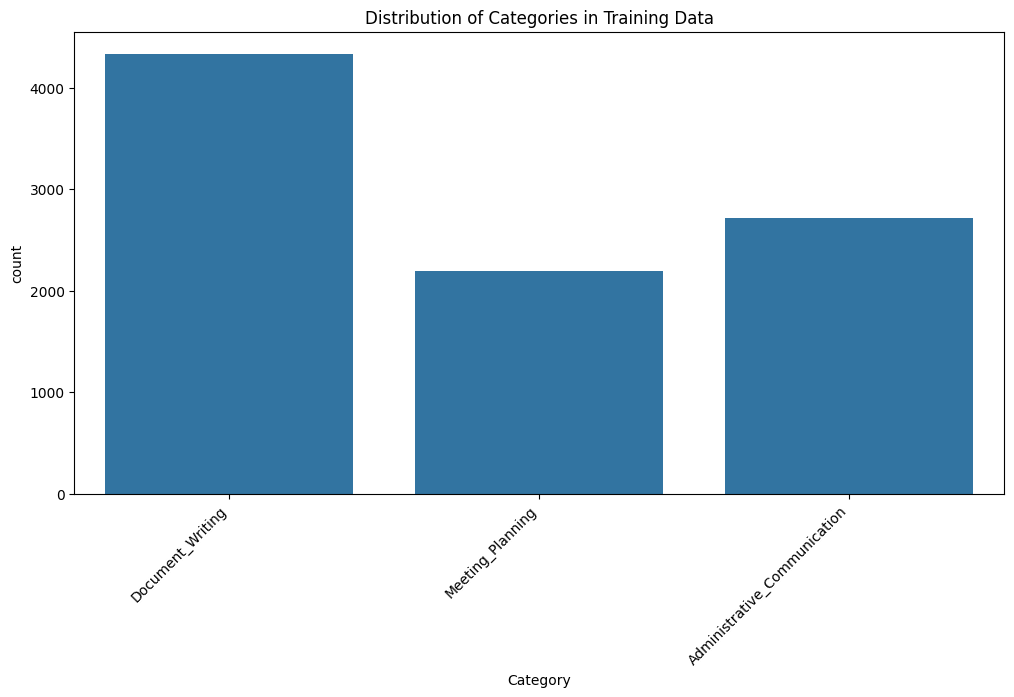

In [125]:

plt.figure(figsize=(12, 6))
sns.countplot(data=df_train, x='Category')
plt.title('Distribution of Categories in Training Data')
plt.xticks(rotation=45, ha='right')
plt.show()

# 4 Fonction d'embedding

In [10]:
# Fonction d'embeddings
def get_text_embeddings(texts, encodeur="sbert"):
    """
    Fonction pour générer des embeddings à partir de texte.
    Supporte plusieurs encodeurs: sbert, tfidf, word2vec, fasttext, etc.
    """
    print(f"🔄 Génération d'embeddings avec {encodeur}...")
    
    if encodeur == "tfidf":
        vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
        X = vectorizer.fit_transform(texts)
        return X.toarray()  # Convertir en array dense

    elif encodeur == "word2vec":
        try:
            import gensim.downloader as api
            wv = api.load("word2vec-google-news-300")
            def embed(text):
                tokens = text.lower().split()
                vectors = [wv[t] for t in tokens if t in wv]
                return np.mean(vectors, axis=0) if vectors else np.zeros(300)
            X = np.array([embed(t) for t in texts])
            return X
        except Exception as e:
            return None

    elif encodeur == "fasttext":
        try:
            import fasttext
            ft = fasttext.load_model('cc.en.300.bin')  # ou cc.fr.300.bin
            X = np.array([ft.get_sentence_vector(t) for t in texts])
            return X
        except Exception as e:
            return None

    elif encodeur == "sbert":
        model = SentenceTransformer('all-MiniLM-L6-v2')
        X = model.encode(texts, show_progress_bar=True)
        return X

    elif encodeur == "mpnet":
        model = SentenceTransformer('paraphrase-mpnet-base-v2')
        X = model.encode(texts, show_progress_bar=True)
        return X

    elif encodeur == "bge":
        model = SentenceTransformer('BAAI/bge-small-en')
        X = model.encode(texts, show_progress_bar=True)
        return X

    elif encodeur == "bert":
        tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        model = AutoModel.from_pretrained("bert-base-uncased")
        model.eval()
        with torch.no_grad():
            X = []
            for text in texts:
                inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
                outputs = model(**inputs)
                cls_vector = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
                X.append(cls_vector)
        return np.array(X)

    else:
        raise ValueError(f"Encodeur non reconnu: {encodeur}")


In [11]:

# 5. Embeddings et Préparation des Features
def embed_and_concat(df, description_column='Description', encodeur="sbert", remove_text_col=True):
    """
    Embeds les descriptions et concatène les vecteurs résultants comme nouvelles colonnes.
    Centralise aussi le preprocessing (suppression de colonnes, etc.)
    """
    print(f"🔄 Embedding de {len(df)} textes avec {encodeur}...")
    
    # 1. Extraire les textes
    texts = df[description_column].astype(str).tolist()

    # 2. Encoder tous les textes
    X_embeddings = get_text_embeddings(texts, encodeur=encodeur)
    
    if X_embeddings is None:
        raise ValueError(f"Échec de l'embedding avec {encodeur}")

    # 3. Convertir en DataFrame
    X_embeddings_df = pd.DataFrame(X_embeddings)
    X_embeddings_df.columns = [f"dim_{i+1}" for i in range(X_embeddings_df.shape[1])]

    # 4. Réinitialiser les index pour concat propre
    df_copy = df.reset_index(drop=True)
    X_embeddings_df = X_embeddings_df.reset_index(drop=True)
    
    # 5. Concat
    result_df = pd.concat([df_copy, X_embeddings_df], axis=1)
    
    # 6. Preprocessing centralisé : supprimer la colonne texte si demandé
    if remove_text_col and description_column in result_df.columns:
        result_df = result_df.drop(columns=[description_column])
        print(f"Colonne '{description_column}' supprimée")
    
    print(f"Embedding terminé. Shape finale: {result_df.shape}")
    return result_df, X_embeddings_df.shape[1]

In [12]:
df_train_embedded, len_embbedings = embed_and_concat(df_train, encodeur="sbert")
df_train_embedded.describe()
print(f"Nombre d'embeddings: {len_embbedings}")

🔄 Embedding de 9246 textes avec sbert...
🔄 Génération d'embeddings avec sbert...


Batches:   0%|          | 0/289 [00:00<?, ?it/s]

Colonne 'Description' supprimée
Embedding terminé. Shape finale: (9246, 385)
Nombre d'embeddings: 384


# 5 Creation de 4 Datasets avec Différentes Stratégies de Preprocessing

Cette section génère 4 datasets selon différentes stratégies de traitement du déséquilibre des classes :

1. **Option 1** : Downsampler la classe dominante + Upsampler les autres avec VAE
2. **Option 2** : Garder la classe dominante + Upsampler les autres avec VAE jusqu'à égaler la dominante  
3. **Option 3** : Garder la classe dominante + Upsampler les autres par duplication aléatoire
4. **Option 4** : Downsampler toutes les classes jusqu'à la plus petite

## Analyse des données pour comprendre la distribution des classes


In [137]:
print("📊 Analyse de la distribution des classes dans les données originales :")
class_counts = df_train_embedded['Category'].value_counts()
print(class_counts)

# Identifier les classes
dominant_class = class_counts.index[0]  # Classe avec le plus d'échantillons
minority_classes = class_counts.index[1:]  # Autres classes
smallest_class_count = class_counts.min()
largest_class_count = class_counts.max()
class_names = class_counts.index.tolist()
class_lens = class_counts.values.tolist()
category_Document_Writing                 = class_names[0],class_lens[0]
category_Administrative_Communication     = class_names[1],class_lens[1]
category_Meeting_Planning                 = class_names[2],class_lens[2]

print("\n🔍 Informations clés :")
for cls, count in zip(class_names, class_lens):
    print(f"Class: {cls}, len: {count}")
print(f"   Classe dominante: {dominant_class} ({largest_class_count} échantillons)")
print(f"   Classes minoritaires: {list(minority_classes)}")
print(f"   Plus petite classe: {smallest_class_count} échantillons")
print(f"   Plus grande classe: {largest_class_count} échantillons")

📊 Analyse de la distribution des classes dans les données originales :
Category
Document_Writing                4334
Administrative_Communication    2715
Meeting_Planning                2197
Name: count, dtype: int64

🔍 Informations clés :
Class: Document_Writing, len: 4334
Class: Administrative_Communication, len: 2715
Class: Meeting_Planning, len: 2197
   Classe dominante: Document_Writing (4334 échantillons)
   Classes minoritaires: ['Administrative_Communication', 'Meeting_Planning']
   Plus petite classe: 2197 échantillons
   Plus grande classe: 4334 échantillons


In [138]:
def balance_classes(df,n_samples):
    from sklearn.utils import resample
    # Downsample the majority class ('Document_Writing')
    df_maj = df[df['Category'] == 'Document_Writing']
    df_maj_ds = resample(df_maj, replace=False, n_samples=n_samples, random_state=42)
    # Combine with the other classes
    df_downsampled = pd.concat([df_maj_ds, df[df['Category'] != 'Document_Writing']])
    
    return df_downsampled

def show_dataframe_info(df):
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Category')
    plt.title('Distribution of Categories in Training Data')
    plt.xticks(rotation=45, ha='right')
    plt.show()



In [155]:
def generate_synthetic_data_vae_from_embeddings(df_class, class_name, num_samples):
    """
    Génère des données synthétiques à partir d'embeddings SBERT déjà calculés.
    
    Args:
        X_class (np.array): Embeddings existants pour une classe (shape: [n_samples, embedding_dim])
        class_name (str): Nom de la classe cible
        num_samples (int): Nombre d'échantillons à générer
    
    Returns:
        synthetic_df (DataFrame): Embeddings synthétiques + label
    """
    df_class = df_class[df_class['Category'] == class_name]
    X_class = df_class.drop(columns=['Category']).values
    
    embedding_dim = X_class.shape[1]
    LATENT_DIM = 32
    EPOCHS = 40
    BATCH_SIZE = 32

    class Sampling(layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            epsilon = tf.random.normal(shape=tf.shape(z_mean))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def build_vae(input_dim, latent_dim):
        inputs = layers.Input(shape=(input_dim,))
        h = layers.Dense(128, activation='relu')(inputs)
        z_mean = layers.Dense(latent_dim, name="z_mean")(h)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
        z = Sampling()([z_mean, z_log_var])
        encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

        latent_inputs = layers.Input(shape=(latent_dim,))
        x = layers.Dense(128, activation='relu')(latent_inputs)
        outputs = layers.Dense(input_dim)(x)
        decoder = Model(latent_inputs, outputs, name="decoder")

        class VAE(Model):
            def __init__(self, encoder, decoder):
                super().__init__()
                self.encoder = encoder
                self.decoder = decoder

            def train_step(self, data):
                if isinstance(data, tuple):
                    data = data[0]
                with tf.GradientTape() as tape:
                    z_mean, z_log_var, z = self.encoder(data)
                    reconstruction = self.decoder(z)
                    reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction))
                    kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
                    total_loss = reconstruction_loss + kl_loss
                grads = tape.gradient(total_loss, self.trainable_weights)
                self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
                return {"loss": total_loss, "recon_loss": reconstruction_loss, "kl_loss": kl_loss}

        vae = VAE(encoder, decoder)
        return vae, encoder, decoder

    print(f"🧠 Entraînement du VAE sur {len(X_class)} embeddings...")
    vae, encoder, decoder = build_vae(embedding_dim, LATENT_DIM)
    vae.compile(optimizer='adam')
    vae.fit(X_class, X_class, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

    z_samples = np.random.normal(size=(num_samples, LATENT_DIM))
    synthetic_embeddings = decoder.predict(z_samples, verbose=0)

    synthetic_df = pd.DataFrame(synthetic_embeddings, columns=[f"dim_{i}" for i in range(1,embedding_dim+1)])
    synthetic_df["Category"] = class_name
    print(f"✅ {num_samples} échantillons synthétiques générés pour '{class_name}'")
    return synthetic_df


In [156]:

# generate_synthetic_data_vae_from_embeddings(df_train_embedded, category_Administrative_Communication[0], category_Document_Writing[1]-category_Administrative_Communication[1])
# generate_synthetic_data_vae_from_embeddings(df_train_embedded, category_Meeting_Planning[0], category_Document_Writing[1]-category_Meeting_Planning[1])


In [157]:
df_train_embedded.head()

,Category,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_375,dim_376,dim_377,dim_378,dim_379,dim_380,dim_381,dim_382,dim_383,dim_384
0,Document_Writing,0.017038,0.084897,0.101675,0.010893,-0.083578,-0.015141,-0.075001,0.001585,-0.071584,...,0.049215,-0.051972,0.031966,0.062290,-0.026727,-0.013043,-0.019002,0.100214,-0.013513,0.052606
1,Document_Writing,-0.088104,0.080596,0.005436,-0.026528,-0.027980,-0.006039,-0.100271,0.046853,0.046540,...,0.044208,0.078636,-0.030758,0.037574,-0.067071,0.002941,0.103063,-0.022785,-0.022606,0.084589
2,Document_Writing,0.071917,0.103629,0.084902,-0.027797,-0.055361,0.024659,-0.072871,0.039179,-0.051645,...,0.059614,0.001020,0.019064,0.031335,-0.056565,-0.000026,0.076706,0.105521,-0.011858,0.013213
3,Document_Writing,0.039065,0.044679,0.115857,0.020627,-0.023733,0.025628,-0.076504,0.014993,-0.031817,...,0.031576,0.042590,0.030317,0.023456,-0.047942,-0.017300,0.074959,0.095864,-0.003564,0.014861
4,Document_Writing,0.038452,0.095613,0.061984,-0.011714,-0.014601,0.097098,-0.091565,-0.012726,-0.108230,...,-0.072644,0.026826,-0.029664,-0.002064,-0.073243,0.002244,-0.007435,0.077487,0.027935,0.027702


## Option 1: Downsampler classe dominante + VAE pour les autres 

   Taille cible calculée (moyenne des minoritaires): 2715
🧠 Entraînement du VAE sur 2197 embeddings...
✅ 518 échantillons synthétiques générés pour 'Meeting_Planning'


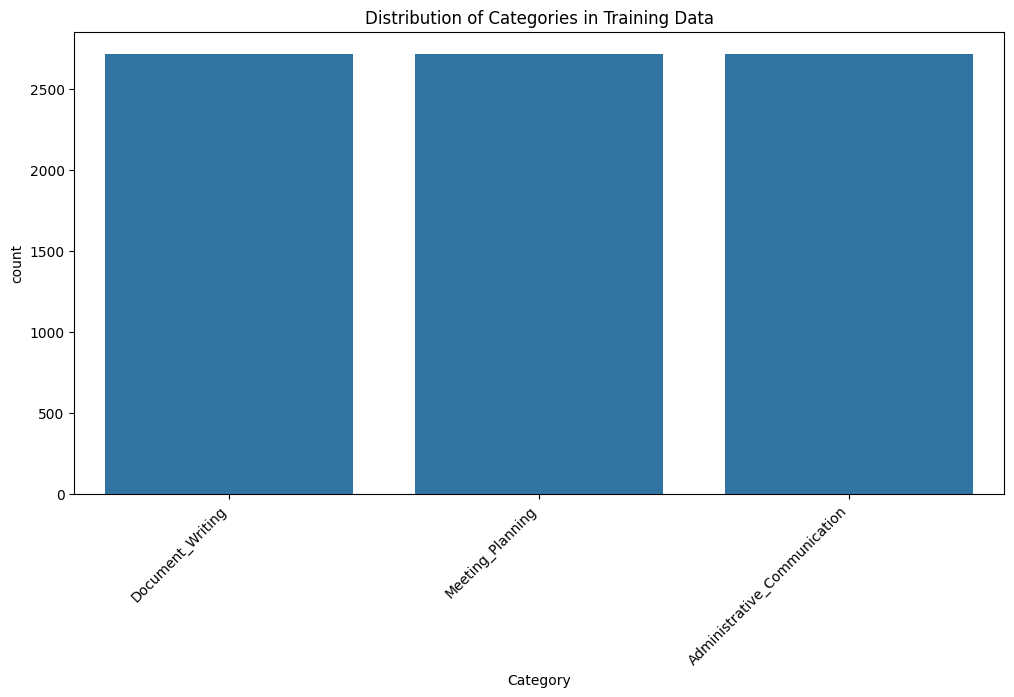

In [158]:
# Calculer la taille cible comme la moyenne des classes minoritaires etr synthetiser jusqu'à que ça atteigne cette taille
minority_counts = [class_counts[class_name] for class_name in minority_classes]
target_size = int(np.max(minority_counts)) 
print(f"   Taille cible calculée (moyenne des minoritaires): {target_size}")

# Downsampler la classe dominante
df_downsample = balance_classes(df_train_embedded, target_size)

synth_data_category_Meeting_Planning = generate_synthetic_data_vae_from_embeddings(df_downsample, category_Meeting_Planning[0], target_size-category_Meeting_Planning[1])

# Concaténer les données downsamplées et synthétiques
df_downsample_VAE = pd.concat([df_downsample,synth_data_category_Meeting_Planning], ignore_index=True)

# Sauvegarder Option 1
df_downsample_VAE.to_csv("dataset_downsample_VAE.csv", index=False)
show_dataframe_info(df_downsample_VAE)

## Option 2 : Garder classe dominante + VAE pour égaler la dominante

   Taille cible (classe majoritaire): 4334
🧠 Entraînement du VAE sur 2197 embeddings...
✅ 2137 échantillons synthétiques générés pour 'Meeting_Planning'
🧠 Entraînement du VAE sur 2715 embeddings...
✅ 1619 échantillons synthétiques générés pour 'Administrative_Communication'


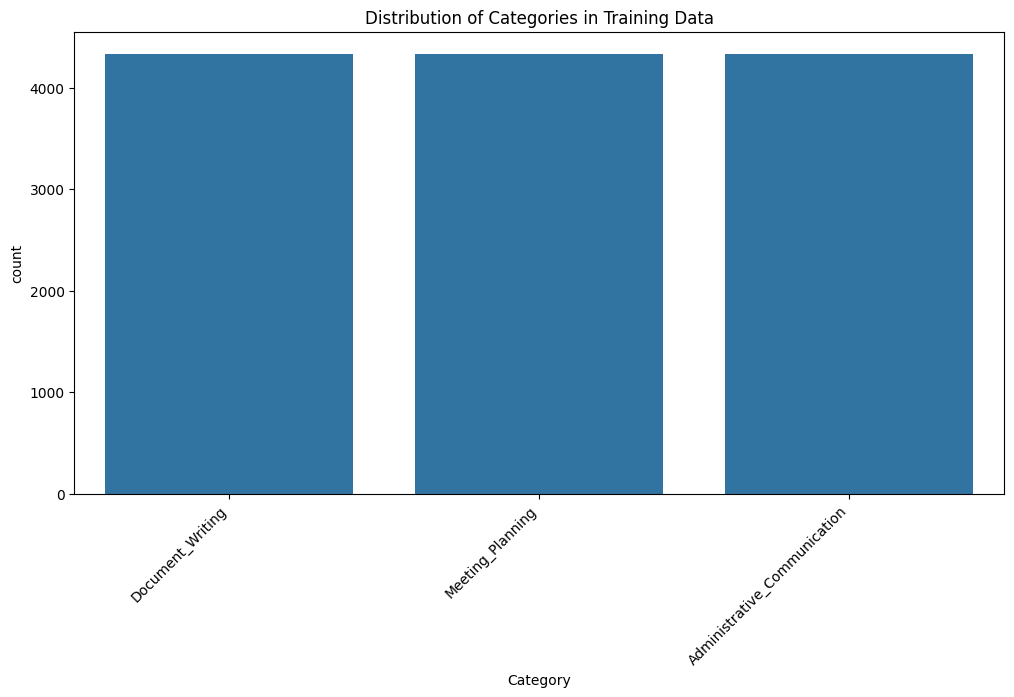

In [159]:

# Taille cible = taille de la classe majoritaire
target_size = class_counts[dominant_class]
print(f"   Taille cible (classe majoritaire): {target_size}")

# Générer données synthétiques pour la classe 'Meeting_Planning'
synth_data_category_Meeting_Planning = generate_synthetic_data_vae_from_embeddings(df_train_embedded, category_Meeting_Planning[0], target_size - category_Meeting_Planning[1])
synth_data_category_Administrative_Communication = generate_synthetic_data_vae_from_embeddings(df_train_embedded, category_Administrative_Communication[0], target_size-category_Administrative_Communication[1])

# Concaténer données originales et synthétiques
df_full_VAE = pd.concat([df_train_embedded, synth_data_category_Meeting_Planning, synth_data_category_Administrative_Communication], ignore_index=True)

# Sauvegarder Option 2
df_full_VAE.to_csv("dataset_full_VAE.csv", index=False)
show_dataframe_info(df_full_VAE)


## Option 3: Garder classe dominante + SMOTE pour égaler

   Taille cible (classe majoritaire): 4334


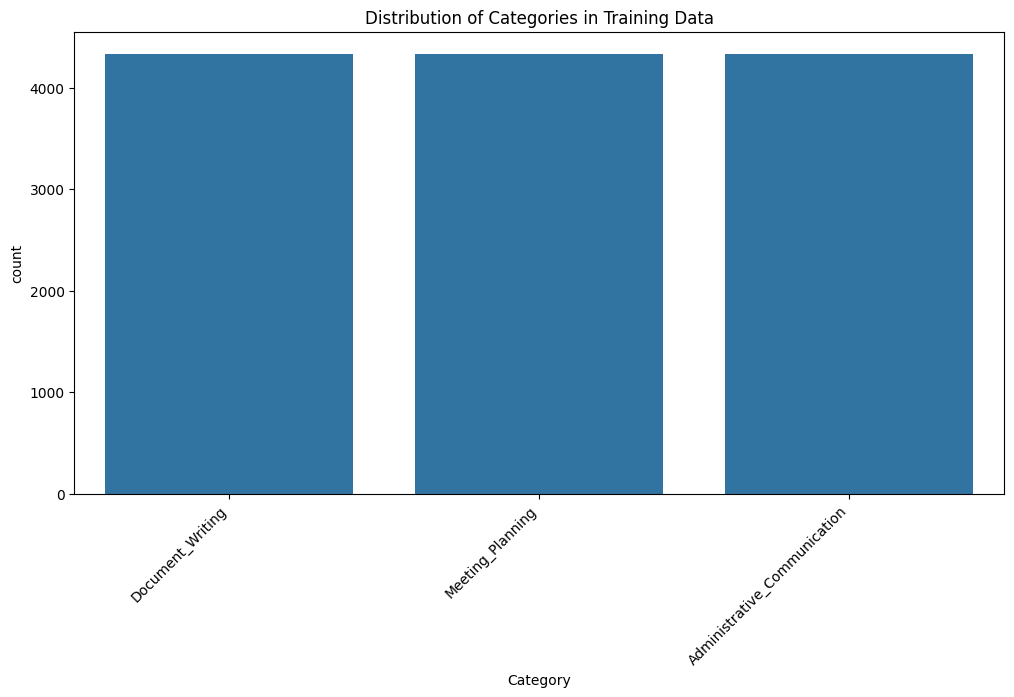

In [160]:
from imblearn.over_sampling import SMOTE

# Taille cible = taille de la classe majoritaire
target_size = class_counts[dominant_class]
print(f"   Taille cible (classe majoritaire): {target_size}")

# Séparer features et labels
X = df_train_embedded.drop(columns=["Category"])
y = df_train_embedded["Category"]

# Initialiser SMOTE
smote = SMOTE(sampling_strategy={category_Meeting_Planning[0]: target_size,
                                 category_Administrative_Communication[0]: target_size},
              random_state=42)

# Appliquer SMOTE
X_res, y_res = smote.fit_resample(X, y)

# Reconstruire DataFrame
df_full_SMOTE = X_res.copy()
df_full_SMOTE["Category"] = y_res

# Sauvegarder Option 3
df_full_SMOTE.to_csv("dataset_full_SMOTE.csv", index=False)
show_dataframe_info(df_full_SMOTE)


## Option 4: Downsampler toutes les classes jusqu'à la plus petite

   Taille cible (plus petite classe): 2197


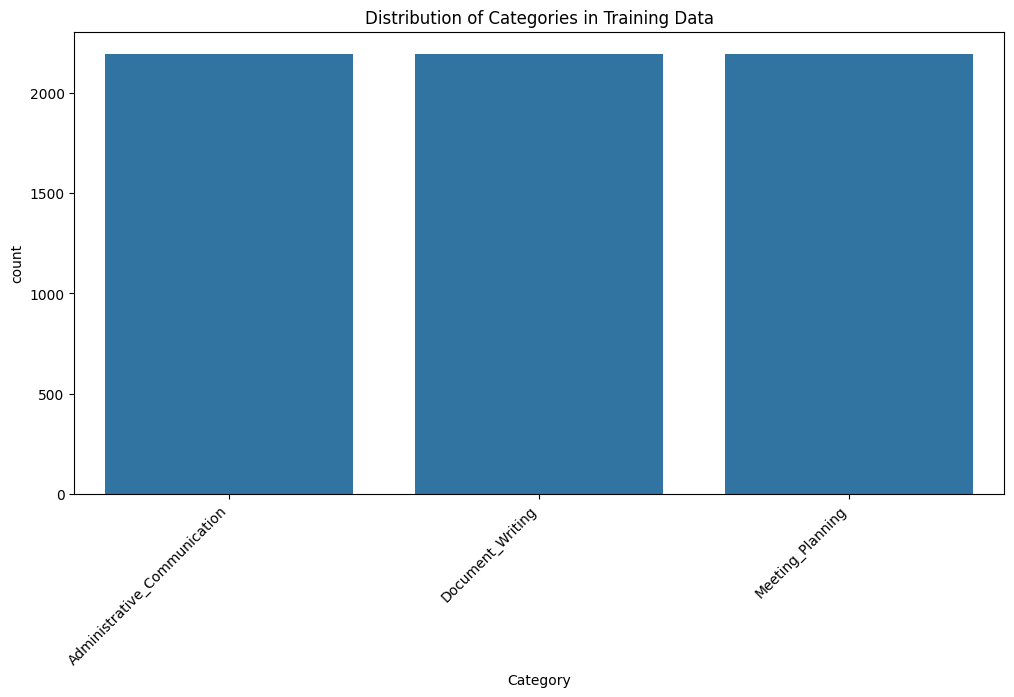

In [161]:
# Trouver la taille minimale parmi les classes
target_size = int(np.min(minority_counts)) 
print(f"   Taille cible (plus petite classe): {target_size}")

# Fonction pour downsampler chaque classe à target_size
def downsample_all_classes(df, target_size):
    return (
        df.groupby("Category", group_keys=False)
          .apply(lambda x: x.sample(n=target_size, random_state=42))
          .reset_index(drop=True)
    )

# Appliquer downsampling
df_downsample_all = downsample_all_classes(df_train_embedded, target_size)

# Sauvegarder Option 4
df_downsample_all.to_csv("dataset_all_downsampled.csv", index=False)
show_dataframe_info(df_downsample_all)

# 6. Modèles de Machine Learning

## Load les différents dataset

In [25]:
datasets = {
    "df_all_downsampled": pd.read_csv("dataset_all_downsampled.csv"),
    "df_downsample_VAE" : pd.read_csv("dataset_downsample_VAE.csv"),
    "df_full_SMOTE"     : pd.read_csv("dataset_full_SMOTE.csv"),
    "df_full_VAE"       : pd.read_csv("dataset_full_VAE.csv"),
}

df_test = pd.read_csv(r"Projet\dataset\test_data.csv")


In [26]:
test_data = embed_and_concat(df_test, encodeur="sbert", remove_text_col=True)[0]


🔄 Embedding de 1498 textes avec sbert...
🔄 Génération d'embeddings avec sbert...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Colonne 'Description' supprimée
Embedding terminé. Shape finale: (1498, 385)


In [27]:
test_data.head()

,Category,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_375,dim_376,dim_377,dim_378,dim_379,dim_380,dim_381,dim_382,dim_383,dim_384
0,Document_Writing,-0.080792,0.065073,-0.015868,-0.022682,-0.029201,0.072091,0.052953,0.071446,-0.000923,...,0.055237,-0.083666,0.035283,-0.075415,0.033046,-0.048752,-0.128386,-0.032916,0.008379,-0.009425
1,Meeting_Planning,-0.045077,0.003195,0.031078,-0.011926,0.034105,0.041765,-0.024783,0.100973,-0.011270,...,-0.070879,0.034509,-0.017779,-0.069702,0.015025,-0.085076,0.003284,-0.055813,-0.055096,0.074790
2,Document_Writing,0.039008,0.030283,0.074319,0.012566,0.036830,0.032827,-0.177416,-0.069261,-0.116805,...,-0.061874,0.084237,-0.018469,-0.041276,-0.019129,-0.031028,0.080017,0.002962,-0.076004,0.091064
3,Document_Writing,0.102136,-0.001543,0.003938,-0.044052,0.057317,0.005521,-0.050619,-0.034060,-0.032440,...,0.052192,-0.009026,-0.041972,0.090203,-0.020012,0.010133,0.003115,0.077138,-0.069734,0.012139
4,Document_Writing,0.015815,-0.022840,-0.057868,-0.021504,0.093398,0.021443,0.043190,-0.032451,-0.016743,...,-0.060831,0.006568,-0.033084,0.019218,-0.014067,-0.094726,0.064818,-0.016463,0.041566,0.011221


## 7 Parametrize Grid Search

In [16]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from scipy.stats import uniform, randint

models_dict = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C": uniform(0.01, 10),
            "solver": ["lbfgs", "liblinear"],
        }
    ),
    "Perceptron": (
        Perceptron(max_iter=1000, random_state=42),
        {
            "penalty": [None, "l2", "l1", "elasticnet"],
            "alpha": uniform(1e-5, 1e-2)
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": randint(50, 200),
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": randint(2, 10)
        }
    ),
    "Linear SVC": (
        LinearSVC(max_iter=1000, random_state=42),
        {
            "C": uniform(0.01, 10)
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": randint(3, 15),
            "weights": ["uniform", "distance"]
        }
    ),
    "MLP Classifier": (
        MLPClassifier(max_iter=300, random_state=42),
        {
            "hidden_layer_sizes": [(50,), (100,), (50,50), (100,50)],
            "activation": ["relu", "tanh"],
            "alpha": uniform(1e-5, 1e-2)
        }
    )
}


In [ ]:
def run_randomized_search_on_dataset(df_train, df_test, models_dict, n_iter=20):
    best_model = None
    best_score = 0
    all_results = {}

    X_train = df_train.drop(columns=["Category"])
    y_train = LabelEncoder().fit_transform(df_train["Category"])
    X_test = df_test.drop(columns=["Category"])
    y_test = LabelEncoder().fit_transform(df_test["Category"])

    for name, (model, param_dist) in models_dict.items():
        print(f"🔍 Training: {name}")
        search = RandomizedSearchCV(
            model,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring="f1_weighted",
            cv=3,
            n_jobs=-1,
            random_state=42
        )
        search.fit(X_train, y_train)

        y_pred = search.best_estimator_.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        f1 = report["weighted avg"]["f1-score"]

        all_results[name] = {
            "best_params": search.best_params_,
            "f1_test": f1,
            "report": report
        }

        if f1 > best_score:
            best_score = f1
            best_model = (name, search.best_estimator_)

    print(f"\n✅ Best model: {best_model[0]} with F1: {best_score:.4f}")## 7 Parametrize Grid Search
    return all_results, best_model


In [16]:
def train_all_models_on_all_datasets(datasets,df_test,models_dict):
    all_results = {}

    for name, df in datasets.items():
        print(f"🔁 Entraînement sur dataset: {name}")
        result = run_randomized_search_on_dataset(df,df_test,models_dict)
        all_results[name] = result

    return all_results

all_results = train_all_models_on_all_datasets(datasets,test_data, models_dict)


🔁 Entraînement sur dataset: df_all_downsampled
🔍 Training: Logistic Regression
🔍 Training: Perceptron
🔍 Training: Random Forest
🔍 Training: Linear SVC
🔍 Training: KNN
🔍 Training: MLP Classifier

✅ Best model: Linear SVC with F1: 0.8410
🔁 Entraînement sur dataset: df_downsample_VAE
🔍 Training: Logistic Regression
🔍 Training: Perceptron
🔍 Training: Random Forest
🔍 Training: Linear SVC
🔍 Training: KNN
🔍 Training: MLP Classifier

✅ Best model: Linear SVC with F1: 0.8485
🔁 Entraînement sur dataset: df_full_SMOTE
🔍 Training: Logistic Regression
🔍 Training: Perceptron
🔍 Training: Random Forest
🔍 Training: Linear SVC
🔍 Training: KNN
🔍 Training: MLP Classifier

✅ Best model: Linear SVC with F1: 0.8528
🔁 Entraînement sur dataset: df_full_VAE
🔍 Training: Logistic Regression
🔍 Training: Perceptron
🔍 Training: Random Forest
🔍 Training: Linear SVC
🔍 Training: KNN
🔍 Training: MLP Classifier

✅ Best model: MLP Classifier with F1: 0.8547


In [17]:
print(all_results)

{'df_all_downsampled': ({'Logistic Regression': {'best_params': {'C': 3.347086111390218, 'solver': 'liblinear'}, 'f1_test': 0.8375393812660779, 'report': {'0': {'precision': 0.796875, 'recall': 0.7727272727272727, 'f1-score': 0.7846153846153846, 'support': 462.0}, '1': {'precision': 0.8728813559322034, 'recall': 0.8595271210013908, 'f1-score': 0.8661527680448493, 'support': 719.0}, '2': {'precision': 0.8187134502923976, 'recall': 0.8832807570977917, 'f1-score': 0.849772382397572, 'support': 317.0}, 'accuracy': 0.8377837116154874, 'macro avg': {'precision': 0.8294899354082004, 'recall': 0.8385117169421518, 'f1-score': 0.8335135116859353, 'support': 1498.0}, 'weighted avg': {'precision': 0.8379773756061043, 'recall': 0.8377837116154874, 'f1-score': 0.8375393812660779, 'support': 1498.0}}}, 'Perceptron': {'best_params': {'alpha': 0.003755401188473625, 'penalty': None}, 'f1_test': 0.8046401314369174, 'report': {'0': {'precision': 0.7140151515151515, 'recall': 0.816017316017316, 'f1-score':

In [ ]:
json = all_results

In [39]:

# Initialiser liste pour stocker les lignes du tableau
rows = []

# Boucle sur chaque dataset
for dataset_name, (models_dict, _) in json.items():
    for model_name, model_info in models_dict.items():
        hyperparams = model_info["best_params"]
        f1_score = model_info["f1_test"]

        # Format des hyperparamètres en chaîne
        hyperparam_str = ", ".join(f"{k}={v}" for k, v in hyperparams.items())

        # Ajouter une ligne au tableau
        rows.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Hyperparameters": hyperparam_str,
            "F1 Score": round(f1_score, 3)
        })

# Convertir en DataFrame
df_results = pd.DataFrame(rows)

# Afficher
print(df_results)


               Dataset                Model                                                            Hyperparameters  F1 Score
0   df_all_downsampled  Logistic Regression                                      C=3.347086111390218, solver=liblinear     0.838
1   df_all_downsampled           Perceptron                                   alpha=0.003755401188473625, penalty=None     0.805
2   df_all_downsampled        Random Forest                        max_depth=20, min_samples_split=5, n_estimators=142     0.819
3   df_all_downsampled           Linear SVC                                                      C=0.21584494295802448     0.841
4   df_all_downsampled                  KNN                                            n_neighbors=14, weights=uniform     0.780
5   df_all_downsampled       MLP Classifier     activation=tanh, alpha=0.009395527090157502, hidden_layer_sizes=(100,)     0.836
6    df_downsample_VAE  Logistic Regression                                      C=1.844347898661

## 8 Evaluation des scores

In [ ]:
from sklearn.metrics import classification_report

def compute_scores(df_train, df_test, model):
    """
    Compute accuracy, recall, precision, F1-score for train and test datasets.
    """
    # Separate features and labels
    X_train = df_train.drop(columns=["Category"])
    y_train = LabelEncoder().fit_transform(df_train["Category"])
    X_test = df_test.drop(columns=["Category"])
    y_test = LabelEncoder().fit_transform(df_test["Category"])

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Compute scores
    train_report = classification_report(y_train, y_train_pred, output_dict=True)
    test_report = classification_report(y_test, y_test_pred, output_dict=True)

    print("📊 Train Scores:")
    print(classification_report(y_train, y_train_pred))
    print("\n📊 Test Scores:")
    print(classification_report(y_test, y_test_pred))

    return train_report, test_report

# Example usage with Random Forest
train_scores, test_scores = compute_scores(datasets["df_full_VAE"], test_data, RandomForestClassifier(random_state=42))

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import pandas as pd

# Séparer features et labels
X_train = df_train.drop(columns=["Category"])
y_train = LabelEncoder().fit_transform(df_train["Category"])
X_test = test_data.drop(columns=["Category"])
y_test = LabelEncoder().fit_transform(test_data["Category"])

# Définir la grille d'hyperparamètres
param_grid_rf = {
    'n_estimators': [100, 150, 181, 200],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 3, 5]
}

results = []

# Tester chaque combinaison
for params in ParameterGrid(param_grid_rf):
    model = RandomForestClassifier(random_state=42, **params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'params': params,
        'f1_test': f1
    })

# Trier les modèles par score f1_test décroissant
results_df = pd.DataFrame(results).sort_values(by="f1_test", ascending=False)

# Afficher les meilleurs
print("Top modèles triés par F1 sur le test set :")


Top modèles triés par F1 sur le test set :
                                               params   f1_test
45  {'max_depth': 25, 'min_samples_split': 5, 'n_e...  0.815945
46  {'max_depth': 25, 'min_samples_split': 5, 'n_e...  0.814765
18  {'max_depth': 15, 'min_samples_split': 3, 'n_e...  0.813576
47  {'max_depth': 25, 'min_samples_split': 5, 'n_e...  0.812579
19  {'max_depth': 15, 'min_samples_split': 3, 'n_e...  0.812285


In [55]:
knn = KNeighborsClassifier(**{'n_neighbors' : 3, 'weights' : 'distance'})
f1 = compute_scores(datasets["df_full_VAE"],test_data,knn)

rfc = RandomForestClassifier(random_state=42, **{'max_depth': 25, 'min_samples_split': 5, 'n_estimators': 150})
f1 = compute_scores(datasets["df_full_VAE"],test_data, rfc)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('rfc', rfc)
    ],
    voting='soft'
)
f1 = compute_scores(datasets["df_full_VAE"],test_data, voting_clf)

📊 Train Scores:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4334
           1       1.00      1.00      1.00      4334
           2       1.00      1.00      1.00      4334

    accuracy                           1.00     13002
   macro avg       1.00      1.00      1.00     13002
weighted avg       1.00      1.00      1.00     13002


📊 Test Scores:
              precision    recall  f1-score   support

           0       0.65      0.82      0.72       462
           1       0.87      0.70      0.77       719
           2       0.77      0.82      0.80       317

    accuracy                           0.76      1498
   macro avg       0.76      0.78      0.76      1498
weighted avg       0.78      0.76      0.76      1498



In [49]:
# ===============================
# Meilleurs modèles par dataset
# ===============================
# df_all_downsampled
print("\n--- df_all_downsampled ---")
compute_scores(datasets["df_all_downsampled"], test_data, LinearSVC(C=0.21584494295980248))
compute_scores(datasets["df_all_downsampled"], test_data, MLPClassifier(activation="tanh", alpha=0.009395527090157502, hidden_layer_sizes=(100,), random_state=42))
compute_scores(datasets["df_all_downsampled"], test_data, LogisticRegression(C=3.347086111390218, solver="liblinear"))

# df_downsample_VAE
print("\n--- df_downsample_VAE ---")
compute_scores(datasets["df_downsample_VAE"], test_data, MLPClassifier(activation="tanh", alpha=0.004677628932479799, hidden_layer_sizes=(50,), random_state=42))
compute_scores(datasets["df_downsample_VAE"], test_data, LogisticRegression(C=1.844347898661638, solver="liblinear"))
compute_scores(datasets["df_downsample_VAE"], test_data, Perceptron(alpha=0.003755401188473625))

# df_full_SMOTE
print("\n--- df_full_SMOTE ---")
compute_scores(datasets["df_full_SMOTE"], test_data, LinearSVC(C=0.5908361216819946))
compute_scores(datasets["df_full_SMOTE"], test_data, MLPClassifier(activation="relu", alpha=0.00408609717152554, hidden_layer_sizes=(100, 50), random_state=42))
compute_scores(datasets["df_full_SMOTE"], test_data, LogisticRegression(C=8.334246408004218, solver="liblinear"))

# df_full_VAE
print("\n--- df_full_VAE ---")
compute_scores(datasets["df_full_VAE"], test_data, MLPClassifier(activation="tanh", alpha=0.009395527090157502, hidden_layer_sizes=(100,), random_state=42))
compute_scores(datasets["df_full_VAE"], test_data, LinearSVC(C=0.21584494295980248))
compute_scores(datasets["df_full_VAE"], test_data, LogisticRegression(C=1.4049386065204184, solver="liblinear"))


--- df_all_downsampled ---
📊 Train Scores:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      2197
           1       0.85      0.89      0.87      2197
           2       0.91      0.90      0.91      2197

    accuracy                           0.88      6591
   macro avg       0.88      0.88      0.88      6591
weighted avg       0.88      0.88      0.88      6591


📊 Test Scores:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       462
           1       0.88      0.86      0.87       719
           2       0.82      0.88      0.85       317

    accuracy                           0.84      1498
   macro avg       0.83      0.84      0.84      1498
weighted avg       0.84      0.84      0.84      1498

📊 Train Scores:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      2197
           1       0.88      0.89      0.88      2197

({'0': {'precision': 0.9051458382736542,
   'recall': 0.8807106598984772,
   'f1-score': 0.8927610805753713,
   'support': 4334.0},
  '1': {'precision': 0.8797510557901755,
   'recall': 0.9132441162898016,
   'f1-score': 0.8961847616891203,
   'support': 4334.0},
  '2': {'precision': 0.9447036864209053,
   'recall': 0.9342408860175357,
   'f1-score': 0.9394431554524362,
   'support': 4334.0},
  'accuracy': 0.9093985540686048,
  'macro avg': {'precision': 0.9098668601615785,
   'recall': 0.9093985540686048,
   'f1-score': 0.9094629992389759,
   'support': 13002.0},
  'weighted avg': {'precision': 0.9098668601615783,
   'recall': 0.9093985540686048,
   'f1-score': 0.909462999238976,
   'support': 13002.0}},
 {'0': {'precision': 0.8259860788863109,
   'recall': 0.7705627705627706,
   'f1-score': 0.7973124300111982,
   'support': 462.0},
  '1': {'precision': 0.8611481975967957,
   'recall': 0.8970792767732962,
   'f1-score': 0.8787465940054496,
   'support': 719.0},
  '2': {'precision': 0.

In [ ]:
from sklearn.ensemble import VotingClassifier

clf1 = MLPClassifier(activation="tanh", alpha=0.009395527090157502, hidden_layer_sizes=(100,), random_state=42)
clf2 = LogisticRegression(C=1.4049386065204184, solver="liblinear")
clf3 = LinearSVC(C=0.21584494295980248)

voting_clf = VotingClassifier(
    estimators=[
        ('mlp', clf1),
        ('logreg', clf2),
        ('linsvc', clf3)
    ],
    voting='hard'  # ou 'soft' si tous les modèles ont predict_proba()
)

print("\n--- Voting Classifier on df_full_VAE ---")
compute_scores(datasets["df_full_VAE"], test_data, voting_clf)



🔗--- Voting Classifier on df_full_VAE ---
📊 Train Scores:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      4334
           1       0.88      0.92      0.90      4334
           2       0.95      0.93      0.94      4334

    accuracy                           0.91     13002
   macro avg       0.91      0.91      0.91     13002
weighted avg       0.91      0.91      0.91     13002


📊 Test Scores:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       462
           1       0.86      0.90      0.88       719
           2       0.86      0.85      0.85       317

    accuracy                           0.85      1498
   macro avg       0.85      0.84      0.85      1498
weighted avg       0.85      0.85      0.85      1498



({'0': {'precision': 0.9096528768426058,
   'recall': 0.8827872634979234,
   'f1-score': 0.8960187353629977,
   'support': 4334.0},
  '1': {'precision': 0.8800441014332966,
   'recall': 0.9208583294877711,
   'f1-score': 0.8999887247716766,
   'support': 4334.0},
  '2': {'precision': 0.9509504811077212,
   'recall': 0.9349330872173511,
   'f1-score': 0.9428737638161722,
   'support': 4334.0},
  'accuracy': 0.9128595600676819,
  'macro avg': {'precision': 0.9135491531278745,
   'recall': 0.9128595600676818,
   'f1-score': 0.9129604079836154,
   'support': 13002.0},
  'weighted avg': {'precision': 0.9135491531278744,
   'recall': 0.9128595600676819,
   'f1-score': 0.9129604079836153,
   'support': 13002.0}},
 {'0': {'precision': 0.8329466357308585,
   'recall': 0.7770562770562771,
   'f1-score': 0.8040313549832027,
   'support': 462.0},
  '1': {'precision': 0.8584656084656085,
   'recall': 0.9026425591098748,
   'f1-score': 0.88,
   'support': 719.0},
  '2': {'precision': 0.8617363344051